# Lecture: Relationships in Space and Time

Time and location add structure to data. A date is not merely a category: observations have an order and a distance in time. Latitude and longitude are not independent measurements: together they identify a position on Earth.

This lesson begins with a time-series example and then combines space and time to examine Hurricane Ian's movement and intensity.


## Learning goals

By the end of this lesson, you should be able to:

- prepare and check an ordered time feature;
- create and interpret an interactive line plot with Plotly Express;
- distinguish trend, seasonality, cycles, and unusual changes;
- explain how latitude and longitude jointly locate an observation;
- create interactive point and animated maps;
- choose useful hover, color, size, and animation mappings; and
- identify important limitations of time-series and spatial displays.


## Plotly Express

Plotly Express is a high-level interface for creating interactive Plotly figures. We conventionally import it as `px`.

Plotly figures can support:

- tooltips that reveal values when the pointer hovers over a mark;
- zooming and panning;
- legends that can hide or reveal categories; and
- animation through ordered frames.

Interactivity adds ways to explore a figure, but it does not correct inaccurate data, an inappropriate chart, or an unsupported conclusion.


In [6]:
import pandas as pd
import plotly.express as px


# Part 1: Time-series example


## Step 1: Question

> **What seasonal pattern appeared in Florida's monthly electricity sales from 2021 through 2025?**

Electricity use can vary with weather, population activity, and the amount of time included in a reporting period. Multiple complete years let us check whether increases and decreases recur during similar parts of the year, although the figure cannot explain why they occur.


## Step 2: Data

Each row represents one calendar month. `electricity_sales_million_kwh` is the electricity sold to ultimate customers across all sectors during that month.

Electricity **sales** are energy accumulated over a month. They are not instantaneous electricity demand, generating capacity, or the highest hourly load.


In [7]:
electricity = pd.read_csv(
    "data/florida_monthly_electricity_sales_2021_2025.csv",
    parse_dates=["month"]
)

electricity.head()


,month,electricity_sales_million_kwh
0,2021-02-01,17135.12051
1,2025-03-01,17907.96624
2,2022-05-01,21317.42929
3,2023-08-01,26988.64343
4,2024-11-01,18897.45894


In [8]:
electricity.tail()


,month,electricity_sales_million_kwh
55,2023-04-01,19226.16240
56,2024-07-01,26549.49240
57,2021-09-01,23143.46995
58,2025-10-01,21842.48152
59,2022-12-01,18819.56260


In [9]:
electricity.info()


<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   month                          60 non-null     datetime64[us]
 1   electricity_sales_million_kwh  60 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.1 KB


In [10]:
electricity.isnull().sum()


month                            0
electricity_sales_million_kwh    0
dtype: int64

### Discussion: check the electricity data

Complete the table using the data dictionary and the output above.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `month` | temporal | datetime | 0 |
| `electricity_sales_million_kwh` | quantitative | float64 | 0 |


## Step 3: Operation

### Create a line plot

A **line plot** displays observations as points and connects them in sequence with line segments. It is especially useful for showing how a quantitative feature changes through ordered time.


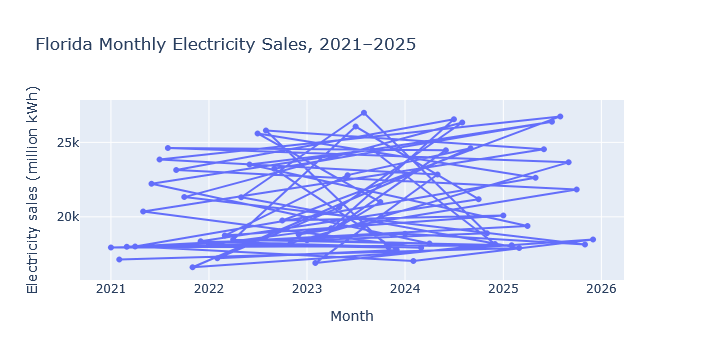

In [11]:
first_electricity_figure = px.line(
    electricity,
    x="month",
    y="electricity_sales_million_kwh",
    markers=True,
    title="Florida Monthly Electricity Sales, 2021–2025",
    labels={
        "month": "Month",
        "electricity_sales_million_kwh": (
            "Electricity sales (million kWh)"
        )
    }
)

first_electricity_figure.show()


### Discussion: inspect the first line plot

1. What do you notice about the line?

2. Inspect the rows. What might explain the unexpected pattern?


In [12]:
electricity[
    ["month", "electricity_sales_million_kwh"]
].head(10)


,month,electricity_sales_million_kwh
0,2021-02-01,17135.12051
1,2025-03-01,17907.96624
2,2022-05-01,21317.42929
3,2023-08-01,26988.64343
4,2024-11-01,18897.45894
5,2023-01-01,18434.14803
6,2024-04-01,18203.63003
7,2021-06-01,22220.70540
8,2025-07-01,26376.68597
9,2022-09-01,23226.35526


### Sort before connecting observations

`.sort_values("month", inplace=True)` rearranges the existing DataFrame into chronological order. With `inplace=True`, Pandas modifies `electricity` directly instead of requiring us to assign the sorted result to a new name.


In [31]:
electricity.sort_values("month", inplace=True)
electricity.head()

,month,electricity_sales_million_kwh
43,2021-01-01,17939.59384
0,2021-02-01,17135.12051
17,2021-03-01,17989.94643
34,2021-04-01,18002.29822
50,2021-05-01,20358.42362


## Step 4: Check

Verify the order, coverage, and number of monthly observations after sorting.


In [30]:
print("Rows:", len(electricity))
print("Unique months:", electricity["month"].nunique())
print("First month:", electricity["month"].min())
print("Last month:", electricity["month"].max())

electricity[["month", "electricity_sales_million_kwh"]].head()


Rows: 60
Unique months: 60
First month: 2021-01-01 00:00:00
Last month: 2025-12-01 00:00:00


,month,electricity_sales_million_kwh
43,2021-01-01,17939.59384
0,2021-02-01,17135.12051
17,2021-03-01,17989.94643
34,2021-04-01,18002.29822
50,2021-05-01,20358.42362


## Step 5: Evidence

`px.line()` places time on the x-axis, electricity sales on the y-axis, and connects observations in DataFrame order. `markers=True` displays the 60 observed monthly values explicitly. The line between markers helps the eye follow the sequence; it does not mean the file contains daily values between months.

The `labels` dictionary replaces stored feature names with audience-friendly labels. Plotly automatically supplies hover information for the mapped features.


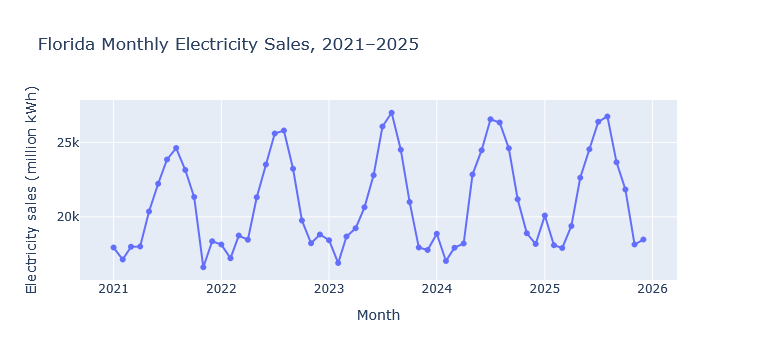

In [15]:
electricity_figure = px.line(
    electricity,
    x="month",
    y="electricity_sales_million_kwh",
    markers=True,
    title="Florida Monthly Electricity Sales, 2021–2025",
    labels={
        "month": "Month",
        "electricity_sales_million_kwh": (
            "Electricity sales (million kWh)"
        )
    }
)

electricity_figure.show()


## Step 6: Conclusion and limitation

### Discussion: interpret the electricity pattern

1. During which months are electricity sales generally highest?

2. During which parts of the year are electricity sales generally lowest?

3. Does a similar pattern appear in each of the five years?

4. Does the figure show a sustained upward or downward trend across the entire period?

5. Which observations support describing the pattern as seasonal?

6. What cannot be concluded from this line plot alone?


## Common time-series patterns

- A **trend** is a sustained long-term increase or decrease.
- **Seasonality** is a pattern that repeats at a fixed calendar frequency.
- A **cycle** rises and falls without a fixed calendar schedule.
- An **unusual event** is a departure that may require contextual investigation.
- **Autocorrelation** means an observation is statistically related to earlier observations.

A line plot can suggest these features, but recognizing a shape is not the same as establishing its cause.


# Part 2: Hurricane Ian through space and time

Hurricane Ian caused catastrophic impacts in Cuba, Florida, and the southeastern United States in September 2022. A table can record where the storm's center was and how its intensity changed. A map makes the geographic sequence much easier to understand.


## The reproducible analysis workflow

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can answer it?
3. **Operation:** What should the code select, calculate, or visualize?
4. **Check:** Does the result have sensible rows, values, units, time order, and locations?
5. **Evidence:** Which figure or result directly answers the question?
6. **Conclusion and limitation:** What claim is supported, and what should we avoid concluding?


## Step 1: Question

> **How did Hurricane Ian's location and intensity change as it moved through the Caribbean, across Florida, and toward the southeastern United States?**


## Step 2: Data

NOAA's HURDAT2 best-track database is a retrospective record constructed after meteorologists assess the available aircraft, satellite, radar, buoy, ship, and land observations.

Each row in the course file represents one best-track observation of a storm at one time. Important features include:

| Feature | Meaning |
| --- | --- |
| `storm_id` | Basin, storm number, and year identifier |
| `storm_name` | Storm name |
| `observation_time` | Date and time in UTC |
| `status` | Cyclone classification at that time |
| `record_identifier` | Special event such as landfall; usually blank |
| `latitude`, `longitude` | Position of the storm's center |
| `maximum_sustained_wind_knots` | Maximum one-minute sustained surface wind |
| `minimum_central_pressure_mb` | Minimum central pressure |

Latitude measures position north or south of the equator. Longitude measures position east or west of the prime meridian. Negative longitude values in this file indicate locations west of the prime meridian. The pair—not either feature alone—identifies a position.


In [16]:
cyclones = pd.read_csv(
    "data/atlantic_tropical_cyclone_observations_2020_2025.csv",
    parse_dates=["observation_time"]
)

cyclones.head()


,storm_id,storm_name,observation_time,status,record_identifier,latitude,longitude,maximum_sustained_wind_knots,minimum_central_pressure_mb
0,AL012020,Arthur,2020-05-16 18:00:00,TD,NaN,28.0,-78.7,30,1008
1,AL012020,Arthur,2020-05-17 00:00:00,TS,NaN,28.9,-78.0,35,1006
2,AL012020,Arthur,2020-05-17 06:00:00,TS,NaN,29.6,-77.6,35,1004
3,AL012020,Arthur,2020-05-17 12:00:00,TS,NaN,30.3,-77.5,35,1003
4,AL012020,Arthur,2020-05-17 18:00:00,TS,NaN,31.0,-77.3,40,1003


In [17]:
cyclones.tail()


,storm_id,storm_name,observation_time,status,record_identifier,latitude,longitude,maximum_sustained_wind_knots,minimum_central_pressure_mb
2525,AL132025,Melissa,2025-10-30 06:00:00,HU,NaN,25.0,-73.8,85,968
2526,AL132025,Melissa,2025-10-30 12:00:00,HU,NaN,26.7,-72.7,90,965
2527,AL132025,Melissa,2025-10-30 18:00:00,HU,NaN,28.9,-70.9,85,967
2528,AL132025,Melissa,2025-10-31 00:00:00,HU,NaN,31.3,-68.7,80,970
2529,AL132025,Melissa,2025-10-31 06:00:00,HU,NaN,34.5,-65.5,75,972


In [18]:
cyclones.info()


<class 'pandas.DataFrame'>
RangeIndex: 2530 entries, 0 to 2529
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   storm_id                      2530 non-null   str           
 1   storm_name                    2530 non-null   str           
 2   observation_time              2530 non-null   datetime64[us]
 3   status                        2530 non-null   str           
 4   record_identifier             122 non-null    str           
 5   latitude                      2530 non-null   float64       
 6   longitude                     2530 non-null   float64       
 7   maximum_sustained_wind_knots  2530 non-null   int64         
 8   minimum_central_pressure_mb   2530 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 216.5 KB


In [19]:
cyclones.isnull().sum()


storm_id                           0
storm_name                         0
observation_time                   0
status                             0
record_identifier               2408
latitude                           0
longitude                          0
maximum_sustained_wind_knots       0
minimum_central_pressure_mb        0
dtype: int64

### Discussion: check the cyclone data

Complete the table using the data dictionary and the output above. Depending on the Pandas version, text may be reported as `str` or `object`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `storm_id` |  |  |  |
| `storm_name` |  |  |  |
| `observation_time` |  |  |  |
| `status` |  |  |  |
| `record_identifier` |  |  |  |
| `latitude` |  |  |  |
| `longitude` |  |  |  |
| `maximum_sustained_wind_knots` |  |  |  |
| `minimum_central_pressure_mb` |  |  |  |


## Step 3: Operation

### Select Hurricane Ian

Storm names can be reused in different years. Select Ian with its unique `storm_id`, `AL092022`, rather than with its name alone. Then sort the selected observations chronologically.


In [20]:
ian = cyclones.loc[
    cyclones["storm_id"] == "AL092022"
].copy()

ian.sort_values("observation_time", inplace=True)

ian.head()


,storm_id,storm_name,observation_time,status,record_identifier,latitude,longitude,maximum_sustained_wind_knots,minimum_central_pressure_mb
1248,AL092022,Ian,2022-09-23 06:00:00,TD,NaN,13.7,-68.1,30,1006
1251,AL092022,Ian,2022-09-23 12:00:00,TD,NaN,14.2,-69.3,30,1006
1255,AL092022,Ian,2022-09-23 18:00:00,TD,NaN,14.6,-70.6,30,1006
1258,AL092022,Ian,2022-09-24 00:00:00,TS,NaN,14.7,-71.7,35,1005
1261,AL092022,Ian,2022-09-24 06:00:00,TS,NaN,14.7,-72.9,35,1005


### Create human-readable categories and time labels

`.replace()` uses the dictionary to exchange each abbreviated status for a readable label. Values not listed in the dictionary remain unchanged.

`.dt.strftime()` formats each datetime as text. `%b` gives an abbreviated month, `%d` the day, `%H` the 24-hour, and `%M` the minute. `UTC` is literal text added to the label.

We retain `observation_time` for sorting and create `time_label` only for display and animation frames.


In [33]:
status_names = {
    "TD": "Tropical depression",
    "TS": "Tropical storm",
    "HU": "Hurricane",
    "SD": "Subtropical depression",
    "SS": "Subtropical storm"
}

ian["status_name"] = ian["status"].replace(status_names)

ian["time_label"] = (
    ian["observation_time"]
    .dt.strftime("%b %d, %H:%M UTC")
)

ian[
    [
        "observation_time",
        "time_label",
        "status",
        "status_name"
    ]
].head()


status,HU,TD,TS
status_name,,,
Hurricane,23,0,0
Tropical depression,0,3,0
Tropical storm,0,0,10


In [35]:
status_names = {
    "TD": "Tropical depression",
    "TS": "Tropical storm",
    "HU": "Hurricane",
    "SD": "Subtropical depression",
    "SS": "Subtropical storm"
}

ian["status_name"] = ian["status"].replace(status_names)

ian["time_label"] = (
    ian["observation_time"]
    .dt.strftime("%b %d, %H:%M UTC")
)

ian["status_name"] = ian['status'].replace(status_names)
pd.crosstab(ian['status_name'],ian['status'])

status,HU,TD,TS
status_name,,,
Hurricane,23,0,0
Tropical depression,0,3,0
Tropical storm,0,0,10


## Step 4: Check

Verify the storm identifier, completeness, chronological order, geographic range, and intensity range.


In [22]:
print("Rows:", len(ian))
print("Storm IDs:", ian["storm_id"].unique())

ian[["observation_time", "latitude", "longitude"]].head()


Rows: 36
Storm IDs: <ArrowStringArray>
['AL092022']
Length: 1, dtype: str


,observation_time,latitude,longitude
1248,2022-09-23 06:00:00,13.7,-68.1
1251,2022-09-23 12:00:00,14.2,-69.3
1255,2022-09-23 18:00:00,14.6,-70.6
1258,2022-09-24 00:00:00,14.7,-71.7
1261,2022-09-24 06:00:00,14.7,-72.9


In [23]:
ian[["observation_time", "latitude", "longitude"]].tail()


,observation_time,latitude,longitude
1303,2022-09-30 00:00:00,29.6,-79.4
1304,2022-09-30 06:00:00,30.3,-79.1
1305,2022-09-30 12:00:00,31.5,-79.0
1306,2022-09-30 18:00:00,33.3,-79.2
1307,2022-09-30 18:05:00,33.3,-79.2


In [24]:
ian[
    [
        "observation_time",
        "latitude",
        "longitude",
        "maximum_sustained_wind_knots",
        "minimum_central_pressure_mb"
    ]
].isna().sum()


observation_time                0
latitude                        0
longitude                       0
maximum_sustained_wind_knots    0
minimum_central_pressure_mb     0
dtype: int64

In [25]:
ian[
    [
        "latitude",
        "longitude",
        "maximum_sustained_wind_knots",
        "minimum_central_pressure_mb"
    ]
].describe().round(1)


,latitude,longitude,maximum_sustained_wind_knots,minimum_central_pressure_mb
count,36.0,36.0,36.0,36.0
mean,22.1,-79.5,74.4,977.5
std,6.3,4.3,33.6,23.6
min,13.7,-83.7,30.0,937.0
25%,14.9,-82.8,40.0,955.0
50%,22.4,-80.8,70.0,982.5
75%,26.9,-78.8,101.2,1003.0
max,33.3,-68.1,140.0,1006.0


## Step 5: Evidence

### Begin with observation points

`px.scatter_map()` uses latitude and longitude to place each observation. Wind speed controls both color and marker size, while the tooltip provides time, status, pressure, and the special record identifier.

Using two visual encodings for wind makes intensity easier to perceive and avoids relying on color alone. Larger, darker-colored markers represent stronger maximum sustained winds under the selected color scale.

Every setting in the code has a specific role:

| Parameter | What it controls |
| --- | --- |
| `ian` | The DataFrame supplied to the figure. |
| `lat`, `lon` | The features that place each marker north/south and east/west. |
| `color` | The quantitative feature mapped to marker color. |
| `size` | The quantitative feature mapped to marker area. |
| `hover_name` | The prominent heading in each hover tooltip. |
| `hover_data` | Additional tooltip features. `True` includes a feature; `:.1f` displays one decimal place. |
| `color_continuous_scale` | The sequence of colors used from lower to higher wind speeds. |
| `range_color` | A fixed wind-speed range for interpreting the colors consistently. |
| `size_max` | The maximum displayed marker size in pixels. |
| `zoom` | The initial map magnification. Larger values show a smaller geographic area. |
| `center` | The latitude and longitude initially placed at the center of the map. |
| `map_style` | The background map tile style. |
| `title` | The figure title. |
| `height` | The figure height in pixels. |


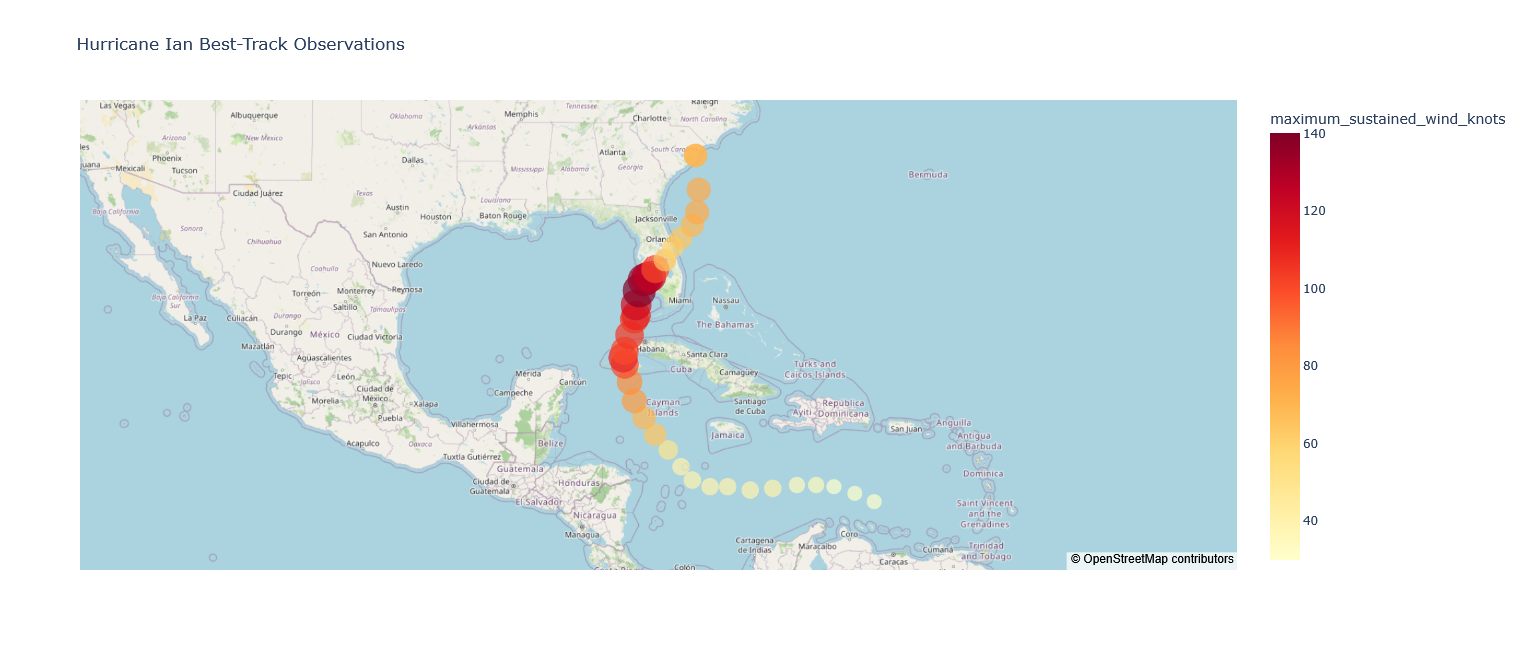

In [52]:
ian_points = px.scatter_map(
    ian,
    lat="latitude",
    lon="longitude",
    color="maximum_sustained_wind_knots",
    size="maximum_sustained_wind_knots",
    hover_name="time_label",
    hover_data={
        "status_name": True,
        "minimum_central_pressure_mb": True,
        "record_identifier": True,
        "latitude": ":.1f",
        "longitude": ":.1f"
    },
    color_continuous_scale="YlOrRd",
    range_color=[30, 140],
    size_max=24,
    zoom=3.5,
    center={"lat": 23.5, "lon": -81.5},
    map_style="open-street-map",
    title="Hurricane Ian Best-Track Observations",
    height=650
)

ian_points.show()


The point map shows where observations occurred and how intensity varied, but overlapping observations make their time sequence difficult to follow. Animation adds that sequence directly.


### Animate the observations through time

`animation_frame="time_label"` creates one frame for each formatted UTC timestamp. Because the DataFrame has already been sorted, `category_orders` preserves that chronological order on the slider.

The timestamp labels connect each frame to an actual date and time. Plotly gives every frame the same playback duration, so the animation emphasizes chronological sequence rather than representing elapsed time proportionally.

The map center, zoom, color range, maximum marker size, and height remain fixed across frames. Fixing these display ranges prevents visual rescaling from being mistaken for change in the data. Wind speed controls both color and marker size, so the dot grows as Ian strengthens and shrinks as it weakens.

Most parameters have the same roles as in the static point map. Here, `animation_frame` identifies the feature that creates frames, and `category_orders` places the timestamp labels in chronological order. We again include wind in `size`, and `size_max=45` makes the change visible while limiting the largest dot.

Plotly supports animation on maps, but the transitions between map frames are steps rather than the smooth motion available for some ordinary scatterplots.


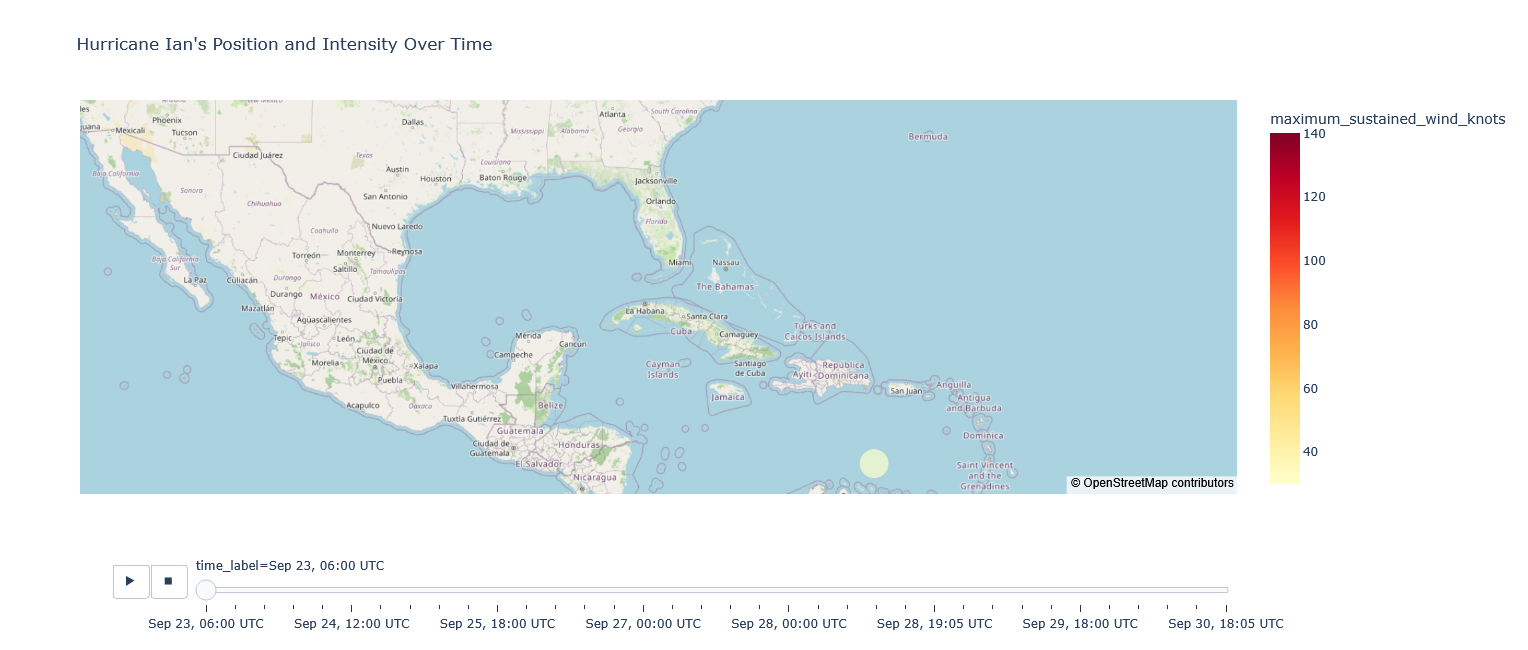

In [53]:
ian_animation = px.scatter_map(
    ian,
    lat="latitude",
    lon="longitude",
    color="maximum_sustained_wind_knots",
    size="maximum_sustained_wind_knots",
    animation_frame="time_label",
    hover_name="time_label",
    hover_data={
        "status_name": True,
        "maximum_sustained_wind_knots": True,
        "minimum_central_pressure_mb": True,
        "record_identifier": True,
        "latitude": ":.1f",
        "longitude": ":.1f"
    },
    color_continuous_scale="YlOrRd",
    range_color=[30, 140],
    category_orders={
        "time_label": ian["time_label"].tolist()
    },
    size_max=45,
    zoom=3.5,
    center={"lat": 23.5, "lon": -81.5},
    map_style="open-street-map",
    title="Hurricane Ian's Position and Intensity Over Time",
    height=650
)

ian_animation.show()


Animation focuses attention on change, but it can make exact comparisons between distant frames difficult. Use the static point map and intensity timeline alongside the animation rather than treating animation as automatically superior.


### Connect the spatial pattern to an intensity timeline

A map is effective for location, but a time-series plot makes the timing and magnitude of intensity changes easier to compare precisely.


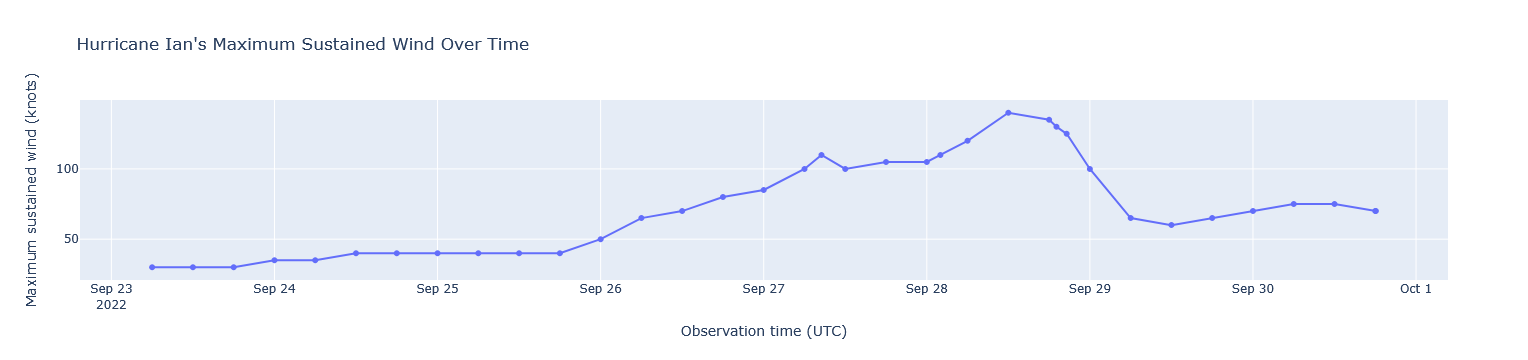

In [54]:
ian_wind = px.line(
    ian,
    x="observation_time",
    y="maximum_sustained_wind_knots",
    markers=True,
    hover_data=[
        "status_name",
        "latitude",
        "longitude",
        "minimum_central_pressure_mb",
        "record_identifier"
    ],
    title="Hurricane Ian's Maximum Sustained Wind Over Time",
    labels={
        "observation_time": "Observation time (UTC)",
        "maximum_sustained_wind_knots": (
            "Maximum sustained wind (knots)"
        )
    }
)

ian_wind.show()


The figures answer complementary questions:

- the line plot shows **when** intensity changed;
- the point map shows **where** observations and stronger winds occurred;
- the animation emphasizes the joint progression of **location, time, and intensity**.


## Step 6: Conclusion and limitation

### Discussion: interpret Hurricane Ian through space and time

1. Where does Ian's track begin, and in what general directions does the storm move?

2. Where is Ian when its maximum sustained winds are strongest?

3. What happens to Ian's wind speed as it crosses Florida? What happens after it returns to the Atlantic?

4. Which changes are easier to identify in the map or animation? Which are easier to identify in the wind time series?

5. Does the animated point show every location affected by Ian? What important hazards or conditions are absent from these figures?

6. Write one conclusion supported by the figures and identify one limitation that should accompany it.


## Discussion: review

1. Why must observations be sorted before creating a line plot or sequential animation?
2. What repeated evidence supports describing the Florida electricity pattern as seasonal, and why might five years still be insufficient for a broader claim?
3. Why would mapping precise personal or household locations require a different privacy review than mapping a hurricane's center?


## Key takeaways

- Time values must be parsed, checked, and ordered before observations are connected.
- A line plot is appropriate when connecting observations through time has a meaningful interpretation.
- Repeated patterns at similar calendar intervals provide evidence of seasonality.
- Latitude and longitude work together to identify positions.
- Point maps, animations, and time-series plots answer different questions.
- Hover information can add useful detail without placing every label on the figure.
- Animation supplements rather than replaces static evidence.
- A mapped track represents the storm's center, not its complete hazard footprint.
- Spatial and temporal visualizations still require checks, supported conclusions, and explicit limitations.
